## AutoML Notebook
Tan-Gatue, Aspiring Data Scientist

# Curve Fitting

Steps:
- from scipy.optimize import curve_fit
- define the function we want to fit
- the curve_fit() function returns 2 objects
- popt - optimal values for the parameters
- pcov - estimated covariance of popt (not important right now)
- calculate sum of squared residuals (SSR)
- print the calculated optimal values and the SSR up to 6 decimals
- generate an array of size 100 that covers the range of x values in equally spaced increments
- plot your x-range against your function


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from itertools import product

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect


def fit_model(model_func, x, y, p0=None, n_points=100, plot=True):
    """
    model_func: function of form f(x, *params)
    x, y: data
    p0: optional initial parameter guess
    n_points: resolution for plotting
    plot: whether to plot fitted curve
    """
    # fit
    if p0 is None:
        popt, pcov = curve_fit(model_func, x, y)
    else:
        popt, pcov = curve_fit(model_func, x, y, p0=p0)

    # predictions
    y_hat = model_func(x, *popt)

    # SSR
    ssr = np.sum((y - y_hat) ** 2)

    # parameter names (skip first arg: x)
    param_names = list(inspect.signature(model_func).parameters.keys())[1:]

    # print parameters
    for name, val in zip(param_names, popt):
        print(f"{name} = {val:.6f}")

    print(f"SSR = {ssr:.6f}")

    # plotting
    if plot:
        x_range = np.linspace(np.min(x), np.max(x), n_points)
        y_range = model_func(x_range, *popt)

        plt.plot(x_range, y_range, 'r')
        plt.scatter(x, y)
        plt.show()

    return {
        "params": dict(zip(param_names, popt)),
        "popt": popt,
        "pcov": pcov,
        "ssr": ssr
    }

In [4]:
# Functional forms
# Linear
def linear(x, m, b):
    return m*x + b


# Quadratic
def quadratic(x, a, b, c):
    return a*x**2 + b*x + c


# Cubic
def cubic(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d


# Frequency (sinusoidal)
def sine(x, A, f, C, D):
    return A * np.sin((2 * np.pi * f * x) + C) + D 

def cos(x, A, f, C, D):
    return A * np.cos((2 * np.pi * f * x) + C) + D 

# Exponential
def exponential(x, a, b, c):
    return a * np.exp(b*x) + c


# Gaussian
def gaussian(x, mean, stdev):
    return (1/np.sqrt(2 * np.pi * stdev**2)) * np.exp(-(x - mean)**2 / (2*stdev**2))


# Power
def power(x, a, b):
    return a * x**b


# Logistic
def logistic(x, A, k, x0):
    return A/(1 + np.exp(-k * (x - x0)))

In [5]:
# COMBO FITTING EXAMPLE

def combo1(x,A,alpha,A2,f,C,D):
    return A*(np.power(x,-alpha)) + A2 * np.sin((2 * np.pi * f * x) + C) + D 

popt, pcov = curve_fit(combo1,x,y)
ssr = sum((y -  combo1(x, *popt))**2)

print(f' SSR = {ssr:.6f}')

x_range = np.linspace(min(x),max(x), 100)

plt.plot(x_range, combo1(x_range, *popt), 'r-')
plt.scatter(x,y)

NameError: name 'x' is not defined

# ML models


## KNN Classifier

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def knn_classifier(
    X, y,
    neighbor_range=range(1, 50),
    monte_carlo_iterations=49,   # matches range(1,50)
    test_size=0.25,
    validation_size=None,
    random_state=None
):
    """
    Generalized KNN analysis with deterministic pseudo–Monte Carlo
    using fixed seeds 
    """

    # ----------------------------
    # Optional train/val/test split
    # ----------------------------
    if validation_size is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
    else:
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        val_fraction = validation_size / (1 - test_size)

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=val_fraction,
            random_state=random_state
        )

        print(
            f"Train size: {len(X_train)}, "
            f"Validation size: {len(X_val)}, "
            f"Test size: {len(X_test)}"
        )

    # ----------------------------
    # Single split accuracy curve
    # ----------------------------
    training_accuracy = []
    test_accuracy = []

    for k in neighbor_range:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)

        training_accuracy.append(model.score(X_train, y_train))
        test_accuracy.append(model.score(X_test, y_test))

    plt.figure(figsize=(8, 5))
    plt.plot(neighbor_range, training_accuracy, label="training accuracy")
    plt.plot(neighbor_range, test_accuracy, label="test accuracy")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("KNN Accuracy vs. n_neighbors")
    plt.show()

    # ----------------------------
    # Pseudo Monte Carlo (FIXED SEEDS)
    # same logic as first script
    # ----------------------------
    monte_carlo_train = pd.DataFrame()
    monte_carlo_test = pd.DataFrame()

    for seed in range(1, monte_carlo_iterations + 1):

        X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed
        )

        training_accuracy_mc = []
        test_accuracy_mc = []

        for k in neighbor_range:
            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_train_mc, y_train_mc)

            training_accuracy_mc.append(
                model.score(X_train_mc, y_train_mc)
            )

            test_accuracy_mc.append(
                model.score(X_test_mc, y_test_mc)
            )

        monte_carlo_train[seed] = training_accuracy_mc
        monte_carlo_test[seed] = test_accuracy_mc

    # ----------------------------
    # Mean + error bars
    # ----------------------------
    plt.figure(figsize=(8, 5))

    plt.errorbar(
        neighbor_range,
        monte_carlo_train.mean(axis=1),
        yerr=monte_carlo_train.std(axis=1) / 2,
        label="training accuracy"
    )

    plt.errorbar(
        neighbor_range,
        monte_carlo_test.mean(axis=1),
        yerr=monte_carlo_test.std(axis=1) / 6,
        label="test accuracy"
    )

    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Monte Carlo KNN Accuracy with Error Bars")
    plt.show()


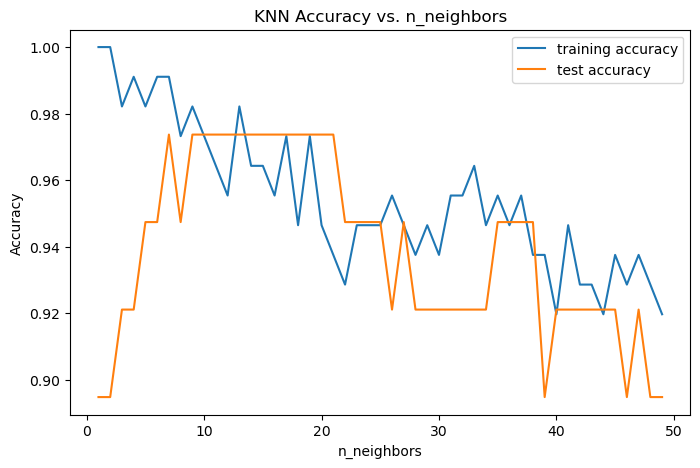

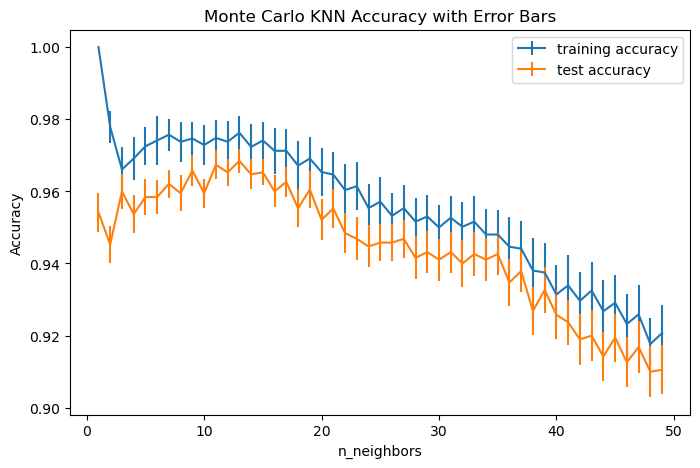

In [81]:
from sklearn.datasets import load_iris
ds = load_iris()
X = pd.DataFrame(ds['data'], columns=ds['feature_names'])
y = ds['target']

knn_classifier(X, y, neighbor_range=range(1, 50), monte_carlo_iterations=50,random_state = 20)

In [83]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

def knn_regressor(X, y, test_size=0.25, n_neighbors_range=range(1, 15), 
                                      seeds=1, plot_results=True):
    """
    Evaluates KNN regression performance over multiple random seeds and n_neighbors values.

    Parameters
    ----------
    X : array-like, feature matrix
    y : array-like, target vector
    test_size : float, fraction of data used as test set
    n_neighbors_range : iterable, values of n_neighbors to evaluate
    seeds : int or iterable, number of seeds (or specific seed values) to run
    plot_results : bool, whether to plot training/test accuracy with error bars

    Returns
    -------
    all_training : pd.DataFrame, training R^2 scores for each seed
    all_test : pd.DataFrame, test R^2 scores for each seed
    """
    all_training = pd.DataFrame()
    all_test = pd.DataFrame()

    if isinstance(seeds, int):
        seeds = range(1, seeds + 1)

    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )

        training_accuracy = []
        test_accuracy = []

        for n in n_neighbors_range:
            reg = KNeighborsRegressor(n_neighbors=n)
            reg.fit(X_train, y_train)
            training_accuracy.append(reg.score(X_train, y_train))
            test_accuracy.append(reg.score(X_test, y_test))

        all_training[seed] = training_accuracy
        all_test[seed] = test_accuracy

    if plot_results:
        plt.figure(figsize=(15, 6))
        plt.errorbar(n_neighbors_range, all_training.mean(axis=1),
                     yerr=all_training.std(axis=1), label="Training $R^2$", 
                     color='blue', marker='o', linestyle='dashed', markersize=10)
        plt.errorbar(n_neighbors_range, all_test.mean(axis=1),
                     yerr=all_test.std(axis=1), label="Test $R^2$", 
                     color='red', marker='^', linestyle='-', markersize=10)
        plt.xlabel("n_neighbors", fontsize=15)
        plt.ylabel("Accuracy ($R^2$)", fontsize=15)
        plt.legend(fontsize=12)
        plt.show()

    return all_training, all_test

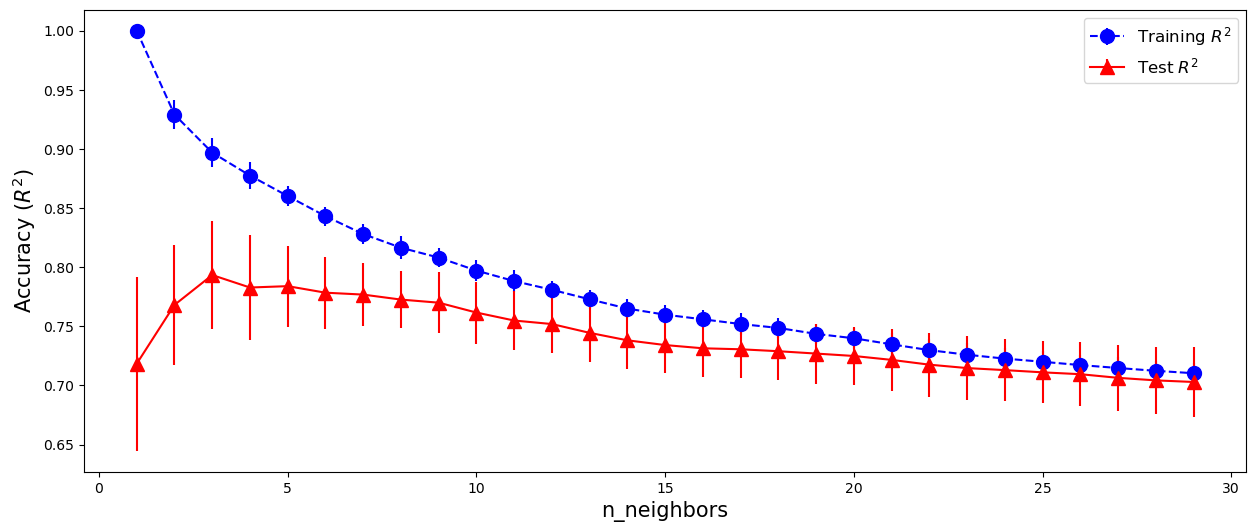

In [84]:
df = pd.read_csv('Boston.csv')
X= df.drop('nox', axis=1)
y=df['nox']
all_train, all_test = knn_regressor(X, y, n_neighbors_range=range(1, 30), seeds=20)

## OLS Regression

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def ols_reg(X, y, df_features=None, 
                                          seeds=100, test_size=0.25, plot_coefficients=True):
    """
    Evaluates Linear Regression over multiple random train/test splits.

    Parameters
    ----------
    X : array-like, feature matrix
    y : array-like, target vector
    df_features : pd.DataFrame or None, required for labeling features in plot
    seeds : int or iterable, number of random seeds or specific seeds
    test_size : float, fraction of data to use as test set
    plot_coefficients : bool, whether to plot feature coefficients

    Returns
    -------
    training_scores : np.ndarray, R² scores on training sets
    test_scores : np.ndarray, R² scores on test sets
    lr_model : fitted LinearRegression object from the last seed
    """
    training_scores = []
    test_scores = []

    if isinstance(seeds, int):
        seeds = range(1, seeds + 1)

    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )
        lr = LinearRegression().fit(X_train, y_train)
        training_scores.append(lr.score(X_train, y_train))
        test_scores.append(lr.score(X_test, y_test))

    training_scores = np.array(training_scores)
    test_scores = np.array(test_scores)

    print("TRAIN SET: Mean = %.4f, Std = %.4f" % (training_scores.mean(), training_scores.std()))
    print("TEST SET:  Mean = %.4f, Std = %.4f" % (test_scores.mean(), test_scores.std()))

    # Plot coefficient magnitudes if requested
    if plot_coefficients:
        plt.figure(figsize=(15, 6))
        plt.plot(lr.coef_.T, '-v', label="Linear Regression", color='blue')
        if df_features is not None:
            plt.xticks(range(df_features.shape[1]), df_features.columns, rotation=90)
        plt.hlines(0, 0, X.shape[1]-1, color='orange')
        plt.xlabel("Feature")
        plt.ylabel("Coefficient magnitude")
        plt.legend()
        plt.show()

        top_idx = np.argmax(np.abs(lr.coef_.T))
        print("Weight of the top predictor = %.4f" % np.abs(lr.coef_.T[top_idx]))
        if df_features is not None:
            print("Top Predictor = %s" % df_features.columns[top_idx])

    return training_scores, test_scores, lr

TRAIN SET: Mean = 0.7432, Std = 0.0130
TEST SET:  Mean = 0.7131, Std = 0.0447


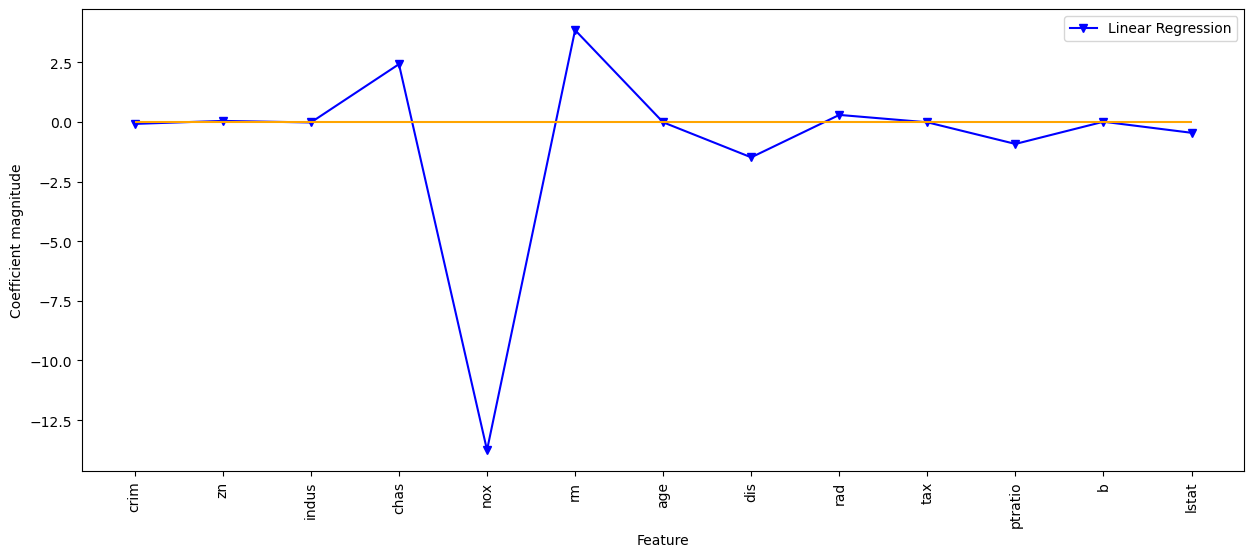

Weight of the top predictor = 13.7566
Top Predictor = nox


(array([0.71680576, 0.73412205, 0.72806595, 0.7375227 , 0.74680342,
        0.74887683, 0.76664702, 0.74448198, 0.72896078, 0.75756861,
        0.75421972, 0.73059199, 0.74454957, 0.77195827, 0.75575597,
        0.74588725, 0.73038842, 0.75091649, 0.7513282 , 0.74191829,
        0.74557738, 0.73300102, 0.74395195, 0.75000177, 0.74751416,
        0.73985927, 0.74472776, 0.76534593, 0.73033374, 0.73789218,
        0.73502615, 0.74740522, 0.75505489, 0.73276896, 0.7537021 ,
        0.75618868, 0.76924953, 0.74761747, 0.75244328, 0.73563489,
        0.76045567, 0.74808726, 0.74914243, 0.7319828 , 0.73376969,
        0.72949437, 0.73568   , 0.75634093, 0.74328019, 0.74620577,
        0.72669364, 0.71789224, 0.77125248, 0.74103357, 0.73546438,
        0.75153881, 0.74731087, 0.74032082, 0.74527436, 0.75502593,
        0.71929647, 0.7350948 , 0.75346411, 0.74904818, 0.76184934,
        0.71266485, 0.75163491, 0.77077686, 0.75512672, 0.7328122 ,
        0.75172254, 0.75220252, 0.7377965 , 0.73

In [58]:
# Load your data into a DataFrame
df = pd.read_csv("Boston.csv")  # adjust path
X = df.drop(columns='medv').values
y = df['medv'].values

# Call the function
ols_reg(X, y, df_features=df, seeds=100, test_size=0.25, plot_coefficients=True)

## Ridge Regression

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def regression_evaluation(X, y, model_class, model_params=None, 
                          df_features=None, seeds=100, test_size=0.25, 
                          plot_coefficients=True):
    """
    Evaluate a regression model over multiple random train/test splits.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Feature matrix.
    y : array-like, shape (n_samples,)
        Target vector.
    model_class : scikit-learn estimator class
        Example: sklearn.linear_model.Ridge, sklearn.linear_model.LinearRegression
    model_params : dict or None
        Parameters to pass to model_class, e.g., {'alpha': 0.4}.
    df_features : pd.DataFrame or list of feature names, optional
        Used for labeling coefficients in the plot.
    seeds : int or iterable
        Number of random seeds or specific seeds to use.
    test_size : float
        Fraction of data used as test set.
    plot_coefficients : bool
        Whether to plot the coefficients from the last trained model.

    Returns
    -------
    training_scores : np.ndarray
        R² scores on training sets.
    test_scores : np.ndarray
        R² scores on test sets.
    model : fitted model object from the last seed.
    """
    if model_params is None:
        model_params = {}

    training_scores = []
    test_scores = []

    if isinstance(seeds, int):
        seeds = range(1, seeds + 1)

    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )
        model = model_class(**model_params).fit(X_train, y_train)
        training_scores.append(model.score(X_train, y_train))
        test_scores.append(model.score(X_test, y_test))

    training_scores = np.array(training_scores)
    test_scores = np.array(test_scores)

    print("TRAIN SET: Mean = %.4f, Std = %.4f" % (training_scores.mean(), training_scores.std()))
    print("TEST SET:  Mean = %.4f, Std = %.4f" % (test_scores.mean(), test_scores.std()))

    if plot_coefficients:
        plt.figure(figsize=(12, 6))
        plt.plot(model.coef_, '-v', color='blue', label=f'{model_class.__name__} coefficients')
        plt.hlines(0, 0, X.shape[1]-1, color='orange')
        plt.xlabel("Feature")
        plt.ylabel("Coefficient magnitude")
        if df_features is not None:
            if hasattr(df_features, "columns"):
                plt.xticks(range(df_features.shape[1]), df_features.columns, rotation=90)
            else:  # assume list of names
                plt.xticks(range(len(df_features)), df_features, rotation=90)
        plt.legend()
        plt.show()

        top_idx = np.argmax(np.abs(model.coef_))
        print("Weight of top predictor = %.4f" % np.abs(model.coef_[top_idx]))
        if df_features is not None:
            feature_name = (df_features.columns[top_idx] if hasattr(df_features, "columns") 
                            else df_features[top_idx])
            print("Top predictor = %s" % feature_name)

    return training_scores, test_scores, model

TRAIN SET: Mean = 0.7425, Std = 0.0130
TEST SET:  Mean = 0.7121, Std = 0.0457


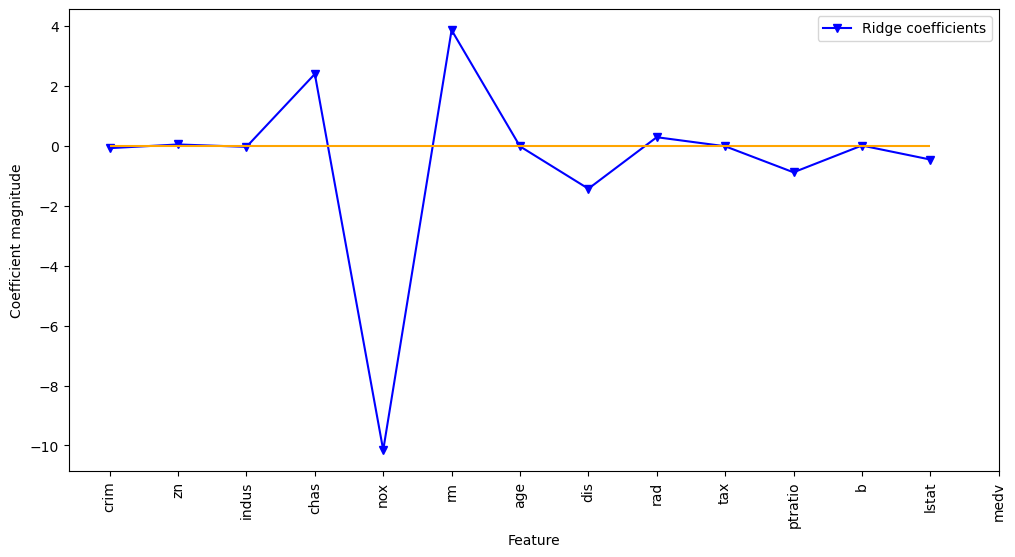

Weight of top predictor = 10.1564
Top predictor = nox


,alpha,0.4
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [47]:
from sklearn.linear_model import Ridge, LinearRegression

# Example 1: Ridge regression
training_scores, test_scores, ridge_model = regression_evaluation(
    X, y,
    model_class=Ridge,
    model_params={'alpha': 0.4},
    df_features=df,  # or a list of names
    seeds=100,
    test_size=0.25)
ridge_model

## Lasso Regression

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

def lasso_evaluation(X, y, alphas=[1.0, 0.1, 0.01], df_features=None, 
                     seeds=50, test_size=0.25, plot_coefficients=True):
    """
    Evaluate Lasso regression over multiple alphas and random train/test splits.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Feature matrix.
    y : array-like, shape (n_samples,)
        Target vector.
    alphas : list of floats
        Regularization strengths to evaluate.
    df_features : pd.DataFrame or list of feature names, optional
        For labeling coefficients in the plot.
    seeds : int or iterable
        Number of random seeds or specific seeds.
    test_size : float
        Fraction of data used as test set.
    plot_coefficients : bool
        Whether to plot the coefficients from the last seed.

    Returns
    -------
    results : dict
        Dictionary with alpha as key containing training/test scores, last model, and number of features used.
    """
    if isinstance(seeds, int):
        seeds = range(1, seeds+1)
    
    results = {}

    for alpha in alphas:
        training_scores = []
        test_scores = []
        last_model = None

        for seed in seeds:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            model = Lasso(alpha=alpha, max_iter=10000).fit(X_train, y_train)
            training_scores.append(model.score(X_train, y_train))
            test_scores.append(model.score(X_test, y_test))
            last_model = model

        training_scores = np.array(training_scores)
        test_scores = np.array(test_scores)

        print(f"ALPHA = {alpha}")
        print("TRAIN SET: Mean = %.4f, Std = %.4f" % (training_scores.mean(), training_scores.std()))
        print("TEST SET:  Mean = %.4f, Std = %.4f" % (test_scores.mean(), test_scores.std()))
        print("Number of features used:", np.sum(last_model.coef_ != 0))
        print("-"*50)

        results[alpha] = {
            "training_scores": training_scores,
            "test_scores": test_scores,
            "model": last_model,
            "n_features_used": np.sum(last_model.coef_ != 0)
        }

    if plot_coefficients:
        plt.figure(figsize=(15, 8))
        for alpha in alphas:
            plt.plot(results[alpha]["model"].coef_, 'o-', label=f"Lasso alpha={alpha}")
        plt.xlabel("Feature")
        plt.ylabel("Coefficient magnitude")
        if df_features is not None:
            if hasattr(df_features, "columns"):
                plt.xticks(range(df_features.shape[1]), df_features.columns, rotation=90)
            else:
                plt.xticks(range(len(df_features)), df_features, rotation=90)
        plt.ylim(-25, 25)
        plt.legend()
        plt.show()

    return results

ALPHA = 1.0
TRAIN SET: Mean = 0.6844, Std = 0.0169
TEST SET:  Mean = 0.6539, Std = 0.0445
Number of features used: 11
--------------------------------------------------
ALPHA = 0.9
TRAIN SET: Mean = 0.6923, Std = 0.0168
TEST SET:  Mean = 0.6625, Std = 0.0445
Number of features used: 11
--------------------------------------------------
ALPHA = 0.5
TRAIN SET: Mean = 0.7162, Std = 0.0165
TEST SET:  Mean = 0.6888, Std = 0.0466
Number of features used: 10
--------------------------------------------------
ALPHA = 0.01
TRAIN SET: Mean = 0.7430, Std = 0.0146
TEST SET:  Mean = 0.7119, Std = 0.0518
Number of features used: 13
--------------------------------------------------


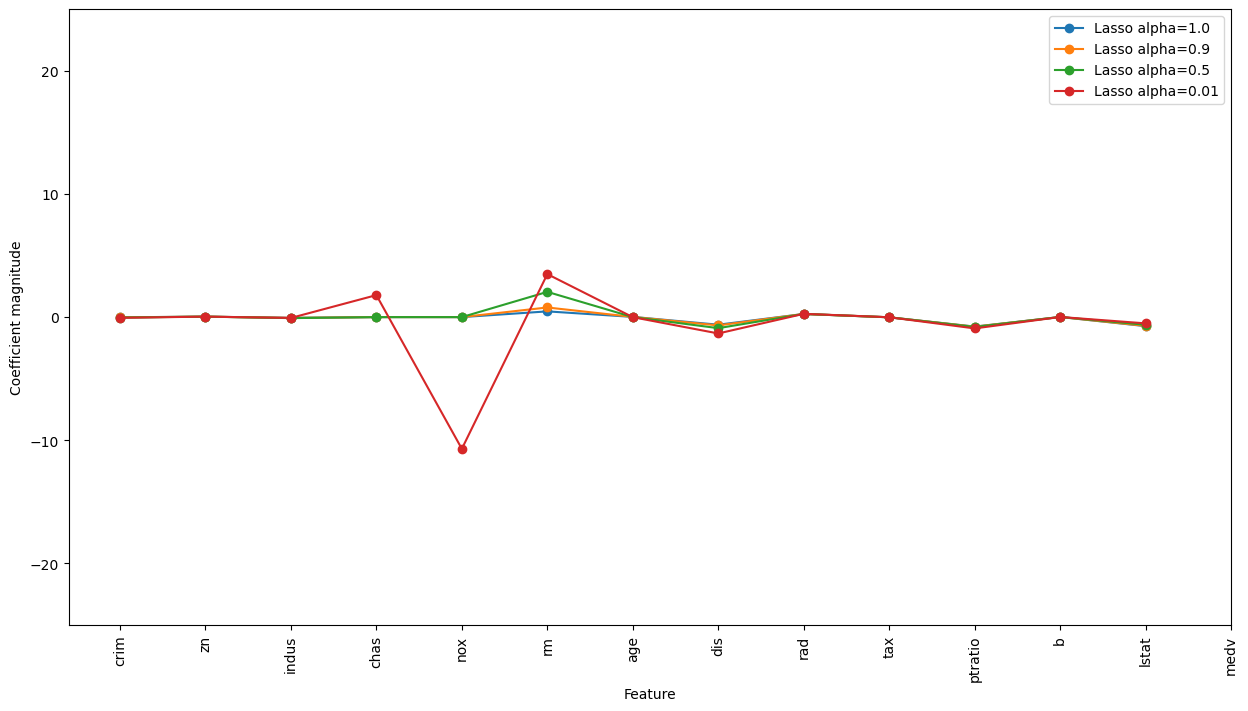

In [57]:
# Assuming df is a pandas DataFrame with target column 'medv'
X = df.drop(columns='medv').values
y = df['medv'].values

results = lasso_evaluation(X, y, alphas=[1.0, 0.9, 0.5, 0.01], df_features=df, seeds=200)

## SVM/Logistic Regression

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def svm_logistic(X, y, model_type='logistic', C=1.0, test_size=0.25, random_state=42, scale_data=True):
    """
    General function for training and evaluating linear classifiers.

    Parameters:
    - X, y: Features and target labels.
    - model_type: 'logistic' for Logistic Regression or 'svm' for Linear SVC.
    - C: Regularization parameter (inverse of strength).
    - test_size: Fraction of data for testing.
    - random_state: Seed for reproducibility.
    - scale_data: Whether to standardize features (recommended for SVM).
    
    Returns:
    - Dictionary containing the trained model, confusion matrix, true labels, and predictions.
    """
    
    # 1. Data Splitting
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # 2. Feature Scaling (optional)
    if scale_data:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    # 3. Model Initialization
    if model_type == 'logistic':
        clf = LogisticRegression(C=C, max_iter=1000, solver='lbfgs')
    elif model_type == 'svm':
        clf = LinearSVC(C=C, max_iter=10000)
    else:
        raise ValueError("model_type must be 'logistic' or 'svm'")
    
    # 4. Model Training
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # 5. Text Evaluation
    print(f"--- Model: {model_type.upper()} (C={C}) ---")
    print(classification_report(y_test, y_pred))
    
    # 6. Confusion Matrix Visualization
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    fig, ax = plt.subplots(figsize=(max(4, confmat.shape[1]), max(4, confmat.shape[0])))
    cax = ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.7)
    plt.colorbar(cax)
    
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
    
    plt.title(f'Confusion Matrix: {model_type.upper()}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()
    
    # 7. Return structured output
    return {'model': clf, 'confusion_matrix': confmat, 'y_test': y_test, 'y_pred': y_pred}

--- Model: LOGISTIC (C=0.5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



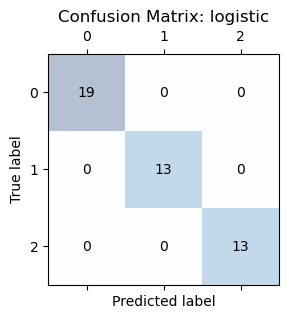

In [66]:
from sklearn.datasets import load_iris
import pandas as pd

# 1. Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Run the AutoML function
# We will use Logistic Regression with a regularization strength of C=1.0
model = svm_logistic(
    X, 
    y, 
    model_type='logistic', 
    C=.5, 
    test_size=0.3, 
    random_state=42
)

# The function will output:
# - A classification report (Precision, Recall, F1-score)
# - A graphical Confusion Matrix

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np

def find_best_C(X, y, C_values=None, cv_folds=5, random_state=42):
    """
    Finds the best C for a Linear SVM using cross-validation.

    Parameters:
    - X, y: Features and labels (scaled is recommended)
    - C_values: List or array of C values to test. Default: logarithmic scale from 0.01 to 100.
    - cv_folds: Number of cross-validation folds
    - random_state: For reproducibility

    Returns:
    - best_C: C value with highest mean cross-validation score
    - cv_scores: Dictionary of C vs mean CV score
    """
    if C_values is None:
        C_values = np.logspace(-2, 2, 10)  # 0.01 → 100

    cv_scores = {}
    for C in C_values:
        clf = LinearSVC(C=C, max_iter=10000, random_state=random_state)
        scores = cross_val_score(clf, X, y, cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state))
        cv_scores[C] = scores.mean()
        print(f"C={C:.4f} → CV Accuracy={scores.mean():.4f}")

    # Find best C
    best_C = max(cv_scores, key=cv_scores.get)
    print(f"\nBest C: {best_C} with CV Accuracy={cv_scores[best_C]:.4f}")

    # Plot
    plt.figure(figsize=(6, 4))
    plt.semilogx(list(cv_scores.keys()), list(cv_scores.values()), marker='o')
    plt.xlabel("C (log scale)")
    plt.ylabel("Mean CV Accuracy")
    plt.title("LinearSVC: C vs CV Accuracy")
    plt.grid(True)
    plt.show()

    return best_C, cv_scores